<a href="https://colab.research.google.com/github/jenleep/datathonPassosMagicos/blob/main/tratamento_inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparação do ambiente

In [ ]:
# importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [ ]:
# importar dados
dados = pd.ExcelFile('/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx')

# verificar quais são as planilhas
print(dados.sheet_names)

['PEDE2022', 'PEDE2023', 'PEDE2024']


In [ ]:
# extrair os dados das planilhas diferentes
df22 = pd.read_excel(dados, 'PEDE2022')
df23 = pd.read_excel(dados, 'PEDE2023')
df24 = pd.read_excel(dados, 'PEDE2024')

# criar a coluna ano para cada planilha
df22['ano'] = 2022
df23['ano'] = 2023
df24['ano'] = 2024

# combinar em um só df
df = pd.concat([df22, df23, df24])

# Limpar a base

Padronizar colunas e variáveis. Unir colunas complementares. Dropar colunas desnecessárias.

## id_aluno

Temos três colunas: RA, Nome, Nome Anonimizado. Como RA já está complento, dispensaremos as outras duas.

In [ ]:
# Usar o RA como id do aluno e garantir as renomeações
df.rename(columns={'RA':'id_aluno'}, inplace=True)
print("Coluna 'RA' renomeada para 'id_aluno'.")

Coluna 'RA' renomeada para 'id_aluno'.


In [ ]:
df['id_aluno'].isna().sum()

np.int64(0)

## idade

Juntar as duas colunas complementares, Idade e Idade 22. Seria redundante utilizar ano ou data de nascimento (Ano nasc, Data de Nasc).

In [ ]:
# Resetar o índice no início da limpeza para evitar problemas de labels duplicados
df = df.reset_index(drop=True)

# unir as colunas de idade
df['idade'] = df['Idade'].combine_first(df['Idade 22'])

In [ ]:
df['Idade'] = pd.to_numeric(df['Idade'], errors='coerce')
df['Idade 22'] = pd.to_numeric(df['Idade 22'], errors='coerce')

df['idade'].describe()

,idade
count,3030.0
unique,36.0
top,10.0
freq,321.0


In [ ]:
# criar uma coluna temporária 'nasc' combinando as fontes disponíveis
df['nasc'] = df['Ano nasc'].fillna(df['Data de Nasc'])

# função para converter diferentes formatos para apenas o ano
def parse_year(val):
    if pd.isna(val): return np.nan
    try:
        return pd.to_datetime(val).year
    except:
        return pd.to_numeric(val, errors='coerce')

# aplicar a função e criar o mapeamento garantindo IDs únicos
df['ano_nasc_temp'] = df['nasc'].apply(parse_year)

# criar o mapa apenas com a primeira ocorrência de nascimento encontrada para cada aluno
mapa_nascimento = df.dropna(subset=['ano_nasc_temp']).drop_duplicates('id_aluno').set_index('id_aluno')['ano_nasc_temp']

# preencher idades nulas: idade = ano_da_linha - ano_nascimento
mask_nulo = df['idade'].isna()
df.loc[mask_nulo, 'idade'] = df.loc[mask_nulo, 'ano'] - df.loc[mask_nulo, 'id_aluno'].map(mapa_nascimento)

# dropar as colunas temporárias
df.drop(columns=['nasc', 'ano_nasc_temp'], inplace=True)

print(f"Idades nulas após o preenchimento: {df['idade'].isna().sum()}")
display(df[['id_aluno', 'ano', 'idade']].tail())

Idades nulas após o preenchimento: 0


,id_aluno,ano,idade
3025,RA-1658,2024,21
3026,RA-1659,2024,21
3027,RA-1252,2024,22
3028,RA-1660,2024,24
3029,RA-1661,2024,21


In [ ]:
# Convert to numeric first to handle any mixed datetime objects, then to int
df['idade'] = pd.to_numeric(df['idade'], errors='coerce').fillna(0).astype(int)
display(df['idade'].describe())

,idade
count,3030.000000
mean,10.895710
std,5.231613
min,0.000000
25%,9.000000
50%,11.000000
75%,14.000000
max,27.000000


## genero

In [ ]:
# ver quais os valores únicos
print(df['Gênero'].unique())

['Menina' 'Menino' 'Feminino' 'Masculino']


In [ ]:
# renomear e padronizar
df['Gênero'] = df['Gênero'].replace({'Menina': 'feminino', 'Menino': 'masculino',
                                     'Feminino': 'feminino', 'Masculino': 'masculino'})
df.rename(columns={'Gênero': 'genero'}, inplace=True)

print(df['genero'].unique())
df['genero'].isna().sum()

['feminino' 'masculino']


np.int64(0)

## fase

In [ ]:
# ver quais os valores únicos
print(df['Fase'].unique())

[7 6 5 4 3 2 1 0 'ALFA' 'FASE 1' 'FASE 2' 'FASE 3' 'FASE 4' 'FASE 5'
 'FASE 6' 'FASE 7' 'FASE 8' '1A' '1B' '1C' '1D' '1E' '1G' '1H' '1J' '1K'
 '1L' '1M' '1N' '1P' '1R' '2A' '2B' '2C' '2D' '2G' '2H' '2I' '2K' '2L'
 '2M' '2N' '2P' '2R' '2U' '3A' '3B' '3C' '3D' '3F' '3G' '3H' '3I' '3K'
 '3L' '3M' '3N' '3P' '3R' '3U' '4A' '4B' '4C' '4F' '4H' '4L' '4M' '4N'
 '4R' '5A' '5B' '5C' '5D' '5F' '5G' '5L' '5M' '5N' '6A' '6L' '7A' '7E'
 '8A' '8B' '8D' '8E' '8F' 9]


In [ ]:
# renomear
df['Fase'] = df['Fase'].replace({'ALFA': 0})
df.rename(columns={'Fase': 'fase'}, inplace=True)

In [ ]:
# função para padronizar
def extract_num(x):
    s = str(x)
    if len(s) > 2:
        return s[-1]
    elif len(s) == 2:
        return s[0]
    else:
        return s

df['fase'] = df['fase'].apply(extract_num)

In [ ]:
# mudar 'fase' == 9 para 8
df.loc[df['fase'] == '9', 'fase'] = '8'

In [ ]:
# ver quais os valores únicos
df['fase'].unique()

array(['7', '6', '5', '4', '3', '2', '1', '0', '8'], dtype=object)

## inst_ensino

In [ ]:
# padronizar e renomear
df['Instituição de ensino'] = df['Instituição de ensino'].replace({'Pública': 'publico',
                                                                   'Escola Pública': 'publico',
                                                                   'Privada - Programa de Apadrinhamento': 'privado',
                                                                   'Rede Decisão': 'privado',
                                                                   'Privada': 'privado',
                                                                   'Privada *Parcerias com Bolsa 100%': 'privado',
                                                                   'Privada - Pagamento por *Empresa Parceira': 'privado',
                                                                   'Concluiu o 3º EM': 'outro',
                                                                   'Bolsista Universitário *Formado (a)': 'privado',
                                                                   'Escola JP II': 'privado',
                                                                   'Privada - Programa de apadrinhamento': 'privado',
                                                                   'Nenhuma das opções acima': 'outro'})

df.rename(columns={'Instituição de ensino': 'inst_ensino'}, inplace=True)

In [ ]:
# ver quais os valores únicos
df['inst_ensino'].unique()

array(['publico', 'privado', 'outro', nan], dtype=object)

## ano_ingresso

In [ ]:
# corrigir a extração do ano de ingresso: converter para numérico diretamente
df.rename(columns={'Ano ingresso': 'ano_ingresso'}, inplace=True)
df['ano_ingresso'] = pd.to_numeric(df['ano_ingresso'], errors='coerce')

print("Anos de ingresso identificados:", df['ano_ingresso'].unique())

Anos de ingresso identificados: [2016 2017 2021 2018 2019 2020 2022 2023 2024]


In [ ]:
df['ano_ingresso'].isna().sum()

np.int64(0)

## pedra

In [ ]:
# juntar as colunas de 2023
df['pedra23'] = df['Pedra 2023'].fillna(df['Pedra 23'])

In [ ]:
# renomear as colunas de 2022 e 2024
df.rename(columns={'Pedra 22': 'pedra22', 'Pedra 2024': 'pedra24'}, inplace=True)

In [ ]:
pedras = ['Pedra 22', 'pedra23', 'Pedra 2024']

In [ ]:
# criar a coluna pedra
df['pedra'] = df.apply(
    lambda row: row[f'pedra{row["ano"] % 100}'] if f'pedra{row["ano"] % 100}' in row else None,
    axis=1
)


In [ ]:
# uniformizar as variáveis de pedra
df['pedra'] = df['pedra'].replace({'Quartzo': 'quartzo', 'Ametista': 'ametista',
                                 'Ágata': 'agata', 'Topázio': 'topazio', 'Agata': 'agata'})





In [ ]:
# substituir 'INCLUIR' com NaN na coluna 'pedra'
df['pedra'] = df['pedra'].replace('INCLUIR', np.nan)


In [ ]:
df['pedra'].isna().sum()

np.int64(185)

## matematica

In [ ]:
# combinar Matem e Mat
df["matematica"] = df["Matem"].combine_first(df["Mat"])

## portugues

In [ ]:
# juntar Portug e Por
df["portugues"] = df["Portug"].combine_first(df["Por"])

## ingles

In [ ]:
# juntar Inglês e Ing
df["ingles"] = df["Inglês"].combine_first(df["Ing"])

## defasagem

In [ ]:
# juntar Defas e Defasagem na coluna unificada
df['defasagem'] = df['Defas'].combine_first(df['Defasagem'])
print("Coluna 'defasagem' unificada com sucesso.")

Coluna 'defasagem' unificada com sucesso.


## inde

In [ ]:
# criar uma colunar com o inde do ano
df['inde'] = np.select(
    [
        df['ano'] == 2022,
        df['ano'] == 2023,
        df['ano'] == 2024
    ],
    [
        df['INDE 22'],
        df['INDE 2023'].fillna(df['INDE 23']),  # caso exista duplicidade
        df['INDE 2024']
    ],
    default=np.nan
)


## indicadores

In [ ]:
# renomear as colunas de indicadores
df.rename(columns={'IAA': 'iaa', 'IEG': 'ieg', 'IPS': 'ips',
                   'IDA': 'ida', 'IPV': 'ipv', 'IAN': 'ian', 'IPP': 'ipp'}, inplace=True)

## ipp para 2020

In [ ]:
# definir e preparar os features numéricos
features_to_prepare = ['inde', 'ida', 'ieg', 'ipp']
for col in features_to_prepare:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# filtrar subset para o ano 2022
df_2022 = df[df['ano'] == 2022].copy()

# Checar valores faltantes em 'ipp'
missing_ipp_count = df_2022['ipp'].isna().sum()
total_rows_2022 = len(df_2022)

print(f"linhas em 2022: {total_rows_2022}")
print(f"valores'ipp' faltantes para 2022: {missing_ipp_count}")
print("features preparadas e subset para 2022 criada.")

linhas em 2022: 860
valores'ipp' faltantes para 2022: 860
features preparadas e subset para 2022 criada.


In [ ]:
# definir as colunas para o processo
cols_imputacao = ['inde', 'ida', 'ieg', 'ipp']

# instanciar o imputer
imputer = KNNImputer(n_neighbors=5)

# ajustar o imputer
imputer.fit(df[cols_imputacao])

# transformar apenas o subset de 2022
df_2022_imputado = imputer.transform(df_2022[cols_imputacao])

# pegamos a última coluna (ipp)
df_2022['ipp'] = df_2022_imputado[:, 3]

# atualizar o df original
df.loc[df['ano'] == 2022, 'ipp'] = df_2022['ipp'].values

print("Imputação corrigida e concluída para o ano 2022.")
print(f"Valores nulos de IPP em 2022 após imputação: {df[df['ano'] == 2022]['ipp'].isna().sum()}")
display(df[df['ano'] == 2022][['id_aluno', 'ipp']].head())

Imputação corrigida e concluída para o ano 2022.
Valores nulos de IPP em 2022 após imputação: 0


,id_aluno,ipp
0,RA-1,7.433333
1,RA-2,7.687500
2,RA-3,7.337500
3,RA-4,7.343750
4,RA-5,7.593750


## atingiu_pv

In [ ]:
# padronizar o nome da coluna para snake_case
df.rename(columns={'Atingiu PV': 'atingiu_pv'}, inplace=True)

# verificar valores nulos
print(f"Valores nulos em atingiu_pv antes: {df['atingiu_pv'].isna().sum()}")

# padronizar valores existentes
df['atingiu_pv'] = df['atingiu_pv'].astype(str).str.replace('\x00', '', regex=True)
df['atingiu_pv'] = df['atingiu_pv'].replace({
    'Sim': 'sim',
    'Não': 'nao',
    'No': 'nao',
    'nan': np.nan
})

Valores nulos em atingiu_pv antes: 2170


In [ ]:
# colunas para usar para preencher os valores faltantes
columns_for_imputation = ['iaa', 'ieg', 'ips', 'ida', 'ipv', 'ian', 'ipp', 'inde', 'atingiu_pv']
df_imputation_subset = df[columns_for_imputation].copy()

pv_mapping = {'sim': 1, 'nao': 0}
df_imputation_subset['atingiu_pv'] = df_imputation_subset['atingiu_pv'].map(pv_mapping)

for col in columns_for_imputation:
    df_imputation_subset[col] = pd.to_numeric(df_imputation_subset[col], errors='coerce')

print(df_imputation_subset.shape)
print(df_imputation_subset['atingiu_pv'].value_counts(dropna=False))

(3030, 9)
atingiu_pv
NaN    2170
0.0     747
1.0     113
Name: count, dtype: int64


In [ ]:
# usar o iterativeimputer para preencher os dados categóricos faltantes
imputer_iter = IterativeImputer(max_iter=10, random_state=42)

imputed_array = imputer_iter.fit_transform(df_imputation_subset)

df_imputed = pd.DataFrame(imputed_array, columns=df_imputation_subset.columns)

print('Iterative imputation completed.')
print('Missing values after imputation:\n', df_imputed.isna().sum())
display(df_imputed.head())

Iterative imputation completed.
Missing values after imputation:
 iaa           0
ieg           0
ips           0
ida           0
ipv           0
ian           0
ipp           0
inde          0
atingiu_pv    0
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,iaa,ieg,ips,ida,ipv,ian,ipp,inde,atingiu_pv
0,8.3,4.1,5.6,4.0,7.278,5.0,7.433333,5.783,0.0
1,8.8,5.2,6.3,6.8,6.778,10.0,7.687500,7.055,0.0
2,0.0,7.9,5.6,5.6,7.556,10.0,7.337500,6.591,0.0
3,8.8,4.5,5.6,5.0,5.278,10.0,7.343750,5.951,0.0
4,7.9,8.6,5.6,5.2,7.389,10.0,7.593750,7.427,0.0


In [ ]:
# Como resetamos o índice do df original, precisamos garantir que o subset e o imputed usem o mesmo referencial
# (Re-executar as células anteriores de subset e imputer se necessário)

# Garantir que os dados imputados sejam tratados como numéricos antes do arredondamento
if df_imputed['atingiu_pv'].dtype == 'object':
    df_imputed['atingiu_pv'] = df_imputed['atingiu_pv'].map({'sim': 1, 'nao': 0})

# Agora podemos arredondar e clipar com segurança
df_imputed['atingiu_pv'] = df_imputed['atingiu_pv'].round().clip(0, 1)

# Mapear para as categorias finais
inv_pv_mapping = {1.0: 'sim', 0.0: 'nao'}
df_imputed['atingiu_pv_final'] = df_imputed['atingiu_pv'].map(inv_pv_mapping)

# Atualizar o DataFrame original usando .values para evitar conflitos de reindexação
for col in [c for c in columns_for_imputation if c != 'atingiu_pv']:
    df.loc[df_imputation_subset.index, col] = df_imputed[col].values

df.loc[df_imputation_subset.index, 'atingiu_pv'] = df_imputed['atingiu_pv_final'].values

print("Distribuição de atingiu_pv após imputação:")
print(df['atingiu_pv'].value_counts())
display(df[columns_for_imputation].head())

Distribuição de atingiu_pv após imputação:
atingiu_pv
nao    2829
sim     201
Name: count, dtype: int64


,iaa,ieg,ips,ida,ipv,ian,ipp,inde,atingiu_pv
0,8.3,4.1,5.6,4.0,7.278,5.0,7.433333,5.783,nao
1,8.8,5.2,6.3,6.8,6.778,10.0,7.687500,7.055,nao
2,0.0,7.9,5.6,5.6,7.556,10.0,7.337500,6.591,nao
3,8.8,4.5,5.6,5.0,5.278,10.0,7.343750,5.951,nao
4,7.9,8.6,5.6,5.2,7.389,10.0,7.593750,7.427,nao


## Dropar

In [ ]:
# dropar colunas que não serão mais utilizadas
df.drop(columns=[
    'INDE 22', 'Idade', 'Idade 22', 'Data de Nasc', 'Ano nasc',
    'Fase ideal', 'Nome', 'Nome Anonimizado', 'Defas', 'Pedra 20',
    'Pedra 21', 'pedra22', 'pedra23', 'Pedra 23', 'Pedra 2023',
    'pedra24', 'Destaque IEG', 'Matem', 'Mat', 'Portug', 'Por',
    'Inglês', 'Ing', 'INDE 2023', 'Destaque IDA', 'Destaque IPV',
    'Destaque IPV.1', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'INDE 23',
    'Fase Ideal', 'Defasagem', 'INDE 2024',  'Cg', 'Cf', 'Ct', 'Nº Av',
    'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3',
    'Rec Av3', 'Avaliador4', 'Rec Av4', 'Avaliador5', 'Avaliador6',
    'Escola', 'Indicado', 'Avaliador5', 'Avaliador6', 'Rec Psicologia',
    'Turma'
], inplace=True)


## indicadores

In [ ]:
indicadores = ['iaa', 'ieg', 'ips', 'ida', 'ipv', 'ian', 'ipp', 'matematica', 'portugues', 'ingles']

df[indicadores].describe()

,iaa,ieg,ips,ida,ipv,ian,ipp,matematica,portugues,ingles
count,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,3030.000000,2846.000000,2845.000000,1091.000000
mean,8.078696,7.920131,6.441738,6.379802,7.518557,7.179043,7.516411,6.161595,6.430668,6.289413
std,2.706866,2.138270,1.914348,1.901150,1.060744,2.535266,0.825875,2.398341,2.138916,2.732636
min,0.000000,0.000000,2.500000,0.000000,2.500000,2.500000,2.500000,0.000000,0.000000,0.000000
25%,7.900000,7.200000,5.600000,5.200000,6.890000,5.000000,7.114583,4.800000,5.200000,4.500000
50%,8.751000,8.500000,7.500000,6.585769,7.500000,5.000000,7.541667,6.300000,6.700000,6.700000
75%,9.500000,9.400000,7.510000,7.800000,8.222000,10.000000,7.968750,8.000000,8.000000,8.500000
max,12.892592,11.625416,10.701746,10.584047,10.010000,10.000000,10.000000,10.000000,10.000000,10.000000


### Garantir que os valores estão < que 10




In [ ]:
# indicadores a verificar
indicators_to_check = ['iaa', 'ieg', 'ips', 'ida', 'ipv']

# consertar onde > 10
outliers_mask = (df[indicators_to_check] > 10).any(axis=1)
df_outliers = df[outliers_mask]

# grupo por ano e ocorrência
outlier_counts_by_year = df_outliers.groupby('ano').size().reset_index(name='outlier_count')

# mostrar resultados e sample
print("Count of rows with indicators > 10 by year:")
print(outlier_counts_by_year)

print("\nSample of outlier rows (indicators and year):")
columns_to_show = ['id_aluno', 'ano'] + indicators_to_check
display(df_outliers[columns_to_show].head(10))

Count of rows with indicators > 10 by year:
    ano  outlier_count
0  2023             31
1  2024            224

Sample of outlier rows (indicators and year):


,id_aluno,ano,iaa,ieg,ips,ida,ipv
892,RA-892,2023,8.0,9.6,6.89,8.3,10.01
894,RA-893,2023,9.5,10.0,7.52,9.3,10.01
895,RA-894,2023,9.5,9.9,7.52,9.4,10.01
896,RA-690,2023,9.0,9.8,6.89,9.1,10.01
898,RA-896,2023,9.5,10.0,6.89,8.5,10.01
899,RA-693,2023,10.0,9.4,6.89,8.5,10.01
904,RA-898,2023,9.0,9.8,3.77,9.4,10.01
948,RA-922,2023,8.5,9.7,3.14,8.4,10.01
951,RA-923,2023,9.5,9.9,7.52,7.3,10.01
952,RA-742,2023,0.0,7.6,7.52,7.5,10.01


In [ ]:
# indicadores a limitar máximo
indicators_to_cap = ['iaa', 'ieg', 'ips', 'ida', 'ipv']

# máximo
df[indicators_to_cap] = df[indicators_to_cap].clip(upper=10)

# verificar o novo máximo
print("Max values after capping:")
print(df[indicators_to_cap].max())

# verificar se tem valores > 10
remaining_outliers = (df[indicators_to_cap] > 10).any(axis=1).sum()
print(f"\nRemaining rows with indicators > 10: {remaining_outliers}")

Max values after capping:
iaa    10.0
ieg    10.0
ips    10.0
ida    10.0
ipv    10.0
dtype: float64

Remaining rows with indicators > 10: 0


# Variáveis novas

## tipo_estudante

In [ ]:
# criar a variável que separa veterano de ingressante
df['tipo_estudante'] = np.where(
    df['ano_ingresso'].isna() | (df['ano_ingresso'] == 0),
    pd.NA,
    np.where(
        df['ano_ingresso'] == df['ano'],
        'ingressante',
        np.where(
            df['ano_ingresso'] < df['ano'],
            'veterano',
            'ajuste_necessario'
        )
    )
)

## tipo_instituicao

In [ ]:
# criar a variável que separa instituições escolares e universitárias
df['fase'] = df['fase'].astype(int)

# função para categorizar
def categorizar_tipo_instituicao(fase):
    if pd.isna(fase):
        return None
    elif fase <= 7:
        return 'escolar'
    else:
        return 'universitario'

# aplicar a função para criar a nova coluna
df['tipo_instituicao'] = df['fase'].apply(categorizar_tipo_instituicao)

print(df['tipo_instituicao'].value_counts())
display(df[['fase', 'tipo_instituicao']].head())

tipo_instituicao
escolar          2865
universitario     165
Name: count, dtype: int64


,fase,tipo_instituicao
0,7,escolar
1,7,escolar
2,7,escolar
3,7,escolar
4,7,escolar


## nivel_ensino

In [ ]:
# função para categorizar fase em grupos
def categorizar_nivel_ensino(fase):
    if pd.isna(fase):
        return None
    elif fase <= 1:
        return 'fundamental1'
    elif fase <= 4:
        return 'fundamental2'
    elif fase <= 7:
        return 'medio'
    else:
        return 'superior'

# aplicar a função
df['nivel_ensino'] = df['fase'].apply(categorizar_nivel_ensino)

print(df['nivel_ensino'].value_counts())
display(df[['fase', 'nivel_ensino']].head())

nivel_ensino
fundamental2    1316
fundamental1    1167
medio            382
superior         165
Name: count, dtype: int64


,fase,nivel_ensino
0,7,medio
1,7,medio
2,7,medio
3,7,medio
4,7,medio


## evadido

In [ ]:
# garantir que 'ano' é inteiro
df['ano'] = df['ano'].astype(int)

# criar conjunto (id, ano) para busca rápida de permanência
pares_aluno_ano = set(zip(df['id_aluno'], df['ano']))

# criar a coluna 'evadido'
df['evadido'] = df.apply(
    lambda row: not ((row['id_aluno'], row['ano'] + 1) in pares_aluno_ano),
    axis=1
)

print(df[['id_aluno', 'ano', 'evadido']].head())
print("\nContagem de evadidos por ano:")
print(df.groupby('ano')['evadido'].value_counts())

  id_aluno   ano  evadido
0     RA-1  2022    False
1     RA-2  2022    False
2     RA-3  2022     True
3     RA-4  2022     True
4     RA-5  2022    False

Contagem de evadidos por ano:
ano   evadido
2022  False       600
      True        260
2023  False       765
      True        249
2024  True       1156
Name: count, dtype: int64


## piorou_defasagem

In [ ]:
df = df.sort_values(by=['id_aluno', 'ano'])

# criar t+1
df['defasagem_proximo_ano'] = df.groupby('id_aluno')['defasagem'].shift(-1)

# remover alunos sem observação futura
df_temp = df[df['defasagem_proximo_ano'].notna()].copy()

# agora sim criar target
df['piorou_defasagem'] = (
    df_temp['defasagem_proximo_ano'] - df['defasagem']
) < 0

# verificação
print("Value counts for 'piorou_defasagem':")
print(df['piorou_defasagem'].value_counts())

print("\nSample:")
display(df[['id_aluno','ano','defasagem','defasagem_proximo_ano','piorou_defasagem']].tail(10))


Value counts for 'piorou_defasagem':
piorou_defasagem
False    2794
True      236
Name: count, dtype: int64

Sample:


,id_aluno,ano,defasagem,defasagem_proximo_ano,piorou_defasagem
1059,RA-992,2023,-2.0,NaN,False
1061,RA-993,2023,0.0,NaN,False
1063,RA-994,2023,0.0,-1.0,True
2051,RA-994,2024,-1.0,NaN,False
1064,RA-995,2023,-2.0,-2.0,False
2130,RA-995,2024,-2.0,NaN,False
1065,RA-996,2023,-1.0,NaN,False
1066,RA-997,2023,0.0,NaN,False
1067,RA-998,2023,-2.0,NaN,False
1068,RA-999,2023,-1.0,NaN,False


In [ ]:
df.drop(columns=['defasagem_proximo_ano'], inplace=True)

## imputar

In [ ]:
# Calculate the average INDE for each stone type to create a mapping
mean_inde_per_pedra = df.groupby('pedra')['inde'].mean().sort_values()
print("Average INDE per Pedra:")
print(mean_inde_per_pedra)

# Define a function to find the closest stone based on INDE
def impute_pedra(inde_val):
    if pd.isna(inde_val):
        return np.nan
    # Finding the stone with the closest mean inde
    return mean_inde_per_pedra.index[(mean_inde_per_pedra - inde_val).abs().argsort()[0]]

# Filter for rows where pedra is null but inde is present
mask_to_impute = df['pedra'].isna() & df['inde'].notna()

# Apply the imputation
df.loc[mask_to_impute, 'pedra'] = df.loc[mask_to_impute, 'inde'].apply(impute_pedra)

print(f"\nImputed {mask_to_impute.sum()} values for 'pedra'.")
print(f"Remaining nulls in 'pedra': {df['pedra'].isna().sum()}")

Average INDE per Pedra:
pedra
quartzo     5.368562
agata       6.591564
ametista    7.524473
topazio     8.439701
Name: inde, dtype: float64

Imputed 185 values for 'pedra'.
Remaining nulls in 'pedra': 0


/tmp/ipython-input-1603/548242691.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return mean_inde_per_pedra.index[(mean_inde_per_pedra - inde_val).abs().argsort()[0]]
/tmp/ipython-input-1603/548242691.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return mean_inde_per_pedra.index[(mean_inde_per_pedra - inde_val).abs().argsort()[0]]
/tmp/ipython-input-1603/548242691.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret

In [ ]:
from sklearn.impute import KNNImputer

# Selecting performance indicators for imputation
cols_impute = ['ida', 'matematica', 'portugues', 'ingles']

# Initialize KNNImputer (using 5 neighbors)
imputer = KNNImputer(n_neighbors=5)

# Fit and transform the data
df[cols_impute] = imputer.fit_transform(df[cols_impute])

print('Missing values after imputation:')
print(df[['matematica', 'ingles']].isna().sum())

display(df[['id_aluno', 'ano', 'matematica', 'portugues', 'ingles']].head())

Missing values after imputation:
matematica    0
ingles        0
dtype: int64


,id_aluno,ano,matematica,portugues,ingles
0,RA-1,2022,2.70,3.50,6.0
1855,RA-1,2023,6.78,5.34,6.9
2958,RA-1,2024,6.18,7.22,6.8
9,RA-10,2022,3.30,2.60,6.4
99,RA-100,2022,7.00,7.80,8.1


In [ ]:
from sklearn.impute import KNNImputer

# 1. Final Imputation for Grades using KNN
imputer_knn = KNNImputer(n_neighbors=5)
cols_grades = ['ida', 'matematica', 'portugues', 'ingles']
df[cols_grades] = imputer_knn.fit_transform(df[cols_grades])

# 2. Final Imputation for 'pedra' based on 'inde'
mean_inde_map = df.groupby('pedra')['inde'].mean().sort_values()
def map_pedra(val):
    if pd.isna(val): return np.nan
    return mean_inde_map.index[(mean_inde_map - val).abs().argsort()[0]]

mask_pedra = df['pedra'].isna() & df['inde'].notna()
df.loc[mask_pedra, 'pedra'] = df.loc[mask_pedra, 'inde'].apply(map_pedra)

# 3. Final verification
print('Remaining missing values in core columns:')
core_cols = ['pedra', 'matematica', 'portugues', 'ingles', 'inde', 'iaa', 'ieg', 'ips', 'ida', 'ipv', 'ian', 'ipp']
print(df[core_cols].isna().sum())

# Re-generate tables
tabela_medias = df.groupby('ano')[core_cols[1:]].mean()
tabela_pedras = df.groupby(['ano', 'pedra']).size().unstack(fill_value=0).reset_index()

Remaining missing values in core columns:
pedra         0
matematica    0
portugues     0
ingles        0
inde          0
iaa           0
ieg           0
ips           0
ida           0
ipv           0
ian           0
ipp           0
dtype: int64


In [ ]:
df_base = df.copy()

## nivel_defasagem

In [ ]:
# definir as condições e escolhas para o nível de defasagem
condicoes = [
    (df['defasagem'] >= 0),
    (df['defasagem'] < 0) & (df['defasagem'] >= -2),
    (df['defasagem'] < -2)
]

escolhas = ['em fase', 'moderada', 'severa']

# criar nova coluna
df['nivel_defasagem'] = np.select(condicoes, escolhas, default=None)

# verificar a distribuição dos novos valores
print(df['nivel_defasagem'].value_counts(dropna=False))

nivel_defasagem
moderada    1642
em fase     1343
severa        45
Name: count, dtype: int64


## permanencia

In [ ]:
# criar a coluna que dirá há quantos anos o aluno está na instituição
df['permanencia'] = df['ano'] - df['ano_ingresso']

display(df[['id_aluno', 'ano', 'ano_ingresso', 'permanencia']].head())

,id_aluno,ano,ano_ingresso,permanencia
0,RA-1,2022,2016,6
1855,RA-1,2023,2016,7
2958,RA-1,2024,2021,3
9,RA-10,2022,2021,1
99,RA-100,2022,2019,3


## jornada

In [ ]:
# garantir ordenação
df = df.sort_values(['id_aluno', 'ano'])

# calcular a diferença da defasagem em relação ao ano anterior
df['diff_defasagem'] = df.groupby('id_aluno')['defasagem'].diff()

# definir as condições para a jornada baseada na defasagem
condicoes = [
    (df['diff_defasagem'] > 0),
    (df['diff_defasagem'] == 0),
    (df['diff_defasagem'] < 0)
]

escolhas = ['avanco', 'neutro', 'recuo']

# criar a coluna 'jornada'
df['jornada'] = np.select(condicoes, escolhas, default=None)

# remover coluna auxiliar e conferir
df.drop(columns=['diff_defasagem'], inplace=True)
print("Nova distribuição da jornada (baseada na defasagem):")
print(df['jornada'].value_counts(dropna=False))

Nova distribuição da jornada (baseada na defasagem):
jornada
None      1661
neutro     633
avanco     500
recuo      236
Name: count, dtype: int64


In [ ]:
df['jornada'].value_counts()

,count
jornada,
neutro,633
avanco,500
recuo,236


## jornada_22_23

In [ ]:
# filtrar a jornada especificamente para o ano de 2023 (que representa a transição 2022 -> 2023)
jornada_22_23 = df[df['ano'] == 2023]['jornada'].value_counts()

print("Jornada de 2022 a 2023 (Baseada na Defasagem):")
print(jornada_22_23)

print("\nDistribuição Percentual:")
print(df[df['ano'] == 2023]['jornada'].value_counts(normalize=True) * 100)

Jornada de 2022 a 2023 (Baseada na Defasagem):
jornada
neutro    311
avanco    185
recuo     104
Name: count, dtype: int64

Distribuição Percentual:
jornada
neutro    51.833333
avanco    30.833333
recuo     17.333333
Name: proportion, dtype: float64


In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada no ano de 2023 (transição 22->23)
mapa_jornada_22_23 = df[df['ano'] == 2023].set_index('id_aluno')['jornada']

# criar a nova coluna no df aplicando esse mapeamento
df['jornada_22_23'] = df['id_aluno'].map(mapa_jornada_22_23)

# verificar as primeiras linhas e a contagem
print("Coluna 'jornada_22_23' criada. Distribuição:")
print(df['jornada_22_23'].value_counts(dropna=False))

display(df[['id_aluno', 'ano', 'jornada', 'jornada_22_23']].head(10))

Coluna 'jornada_22_23' criada. Distribuição:
jornada_22_23
neutro    861
None      711
NaN       651
avanco    522
recuo     285
Name: count, dtype: int64


,id_aluno,ano,jornada,jornada_22_23
0,RA-1,2022,None,avanco
1855,RA-1,2023,avanco,avanco
2958,RA-1,2024,neutro,avanco
9,RA-10,2022,None,NaN
99,RA-100,2022,None,NaN
1072,RA-1000,2023,None,None
2225,RA-1000,2024,neutro,None
1074,RA-1001,2023,None,None
2227,RA-1001,2024,neutro,None
1075,RA-1002,2023,None,None


## jornada_23_24

In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada no ano de 2024 (transição 23->24)
mapa_jornada_23_24 = df[df['ano'] == 2024].set_index('id_aluno')['jornada']

# criar a nova coluna no df_base aplicando esse mapeamento
df['jornada_23_24'] = df['id_aluno'].map(mapa_jornada_23_24)

# verificar as primeiras linhas e a contagem
print("Coluna 'jornada_23_24' criada. Distribuição:")
print(df['jornada_23_24'].value_counts(dropna=False))

display(df[['id_aluno', 'ano', 'jornada', 'jornada_23_24']].head(10))

Coluna 'jornada_23_24' criada. Distribuição:
jornada_23_24
avanco    858
neutro    840
NaN       637
None      387
recuo     308
Name: count, dtype: int64


,id_aluno,ano,jornada,jornada_23_24
0,RA-1,2022,None,neutro
1855,RA-1,2023,avanco,neutro
2958,RA-1,2024,neutro,neutro
9,RA-10,2022,None,NaN
99,RA-100,2022,None,NaN
1072,RA-1000,2023,None,neutro
2225,RA-1000,2024,neutro,neutro
1074,RA-1001,2023,None,neutro
2227,RA-1001,2024,neutro,neutro
1075,RA-1002,2023,None,neutro


## jornada_inde

In [ ]:
# garantir que o INDE seja numérico no df_base
df['inde'] = pd.to_numeric(df['inde'], errors='coerce')

# calcular a diferença do INDE em relação ao ano anterior
df['diff_inde'] = df.groupby('id_aluno')['inde'].diff()

# definir as condições com uma margem de tolerância
threshold = 0.1
condicoes_inde = [
    (df['diff_inde'] > threshold),
    (df['diff_inde'].abs() <= threshold),
    (df['diff_inde'] < -threshold)
]

escolhas = ['avanco', 'neutro', 'recuo']

# criar a coluna jornada_inde
df['jornada_inde'] = np.select(condicoes_inde, escolhas, default=None)

# limpeza e verificação
df.drop(columns=['diff_inde'], inplace=True)
print(f"Distribuição da jornada baseada no INDE (margem: {threshold}):")
print(df['jornada_inde'].value_counts(dropna=False))

Distribuição da jornada baseada no INDE (margem: 0.1):
jornada_inde
None      1661
recuo      648
avanco     570
neutro     151
Name: count, dtype: int64


## jornada_inde_22_23

In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada_inde no ano de 2023
mapa_jornada_inde_22_23 = df[df['ano'] == 2023].set_index('id_aluno')['jornada_inde']

# criar a nova coluna no df_base aplicando esse mapeamento
df['jornada_inde_22_23'] = df['id_aluno'].map(mapa_jornada_inde_22_23)

# verificar a contagem
print("Coluna 'jornada_inde_22_23' criada. Distribuição:")
print(df['jornada_inde_22_23'].value_counts(dropna=False))

Coluna 'jornada_inde_22_23' criada. Distribuição:
jornada_inde_22_23
recuo     748
avanco    713
None      711
NaN       651
neutro    207
Name: count, dtype: int64


## jornada_inde_23_24

In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada_inde no ano de 2024
mapa_jornada_inde_23_24 = df[df['ano'] == 2024].set_index('id_aluno')['jornada_inde']

# criar a nova coluna no df aplicando esse mapeamento
df['jornada_inde_23_24'] = df['id_aluno'].map(mapa_jornada_inde_23_24)

# verificar a contagem
print("Coluna 'jornada_inde_23_24' criada. Distribuição:")
print(df['jornada_inde_23_24'].value_counts(dropna=False))

Coluna 'jornada_inde_23_24' criada. Distribuição:
jornada_inde_23_24
recuo     953
avanco    854
NaN       637
None      387
neutro    199
Name: count, dtype: int64


## jornada_pedra

In [ ]:
# definir o ranking das pedras (Quartzo < Ametista < Ágata < Topázio)
rank_pedras = {
    'quartzo': 1,
    'ametista': 2,
    'agata': 3,
    'topazio': 4
}

# mapear para valores numéricos temporários para o cálculo
df['pedra_rank'] = df['pedra'].map(rank_pedras)

# calcular a diferença de rank em relação ao ano anterior por aluno
df['diff_pedra'] = df.groupby('id_aluno')['pedra_rank'].diff()

# definir as condições de jornada
condicoes_pedra = [
    (df['diff_pedra'] > 0),
    (df['diff_pedra'] == 0),
    (df['diff_pedra'] < 0)
]

escolhas = ['avanco', 'neutro', 'recuo']

# criar a coluna jornada_pedra
df['jornada_pedra'] = np.select(condicoes_pedra, escolhas, default=None)

# remover colunas auxiliares e exibir contagem
df.drop(columns=['pedra_rank', 'diff_pedra'], inplace=True)
print("Distribuição da jornada baseada na Pedra:")
print(df['jornada_pedra'].value_counts(dropna=False))

Distribuição da jornada baseada na Pedra:
jornada_pedra
None      1661
neutro     648
avanco     411
recuo      310
Name: count, dtype: int64


## jornada_pedra_22_23

In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada_pedra no ano de 2023
mapa_jornada_pedra_22_23 = df[df['ano'] == 2023].set_index('id_aluno')['jornada_pedra']

# criar a nova coluna no df aplicando esse mapeamento
df['jornada_pedra_22_23'] = df['id_aluno'].map(mapa_jornada_pedra_22_23)

# verificar a contagem
print("Coluna 'jornada_pedra_22_23' criada. Distribuição:")
print(df['jornada_pedra_22_23'].value_counts(dropna=False))

Coluna 'jornada_pedra_22_23' criada. Distribuição:
jornada_pedra_22_23
neutro    839
None      711
NaN       651
avanco    424
recuo     405
Name: count, dtype: int64


## jornada_pedra_23_24

In [ ]:
# criar um mapeamento do id_aluno para o valor da jornada_pedra no ano de 2024
mapa_jornada_pedra_23_24 = df[df['ano'] == 2024].set_index('id_aluno')['jornada_pedra']

# criar a nova coluna no df aplicando esse mapeamento
df['jornada_pedra_23_24'] = df['id_aluno'].map(mapa_jornada_pedra_23_24)

# verificar a contagem
print("Coluna 'jornada_pedra_23_24' criada. Distribuição:")
#print(df['jornada_pedra_23_24'].value_counts(dropna=False))

Coluna 'jornada_pedra_23_24' criada. Distribuição:


# Df para modelo

In [ ]:
df_modelo = df.copy()

In [ ]:
df_modelo.drop(columns=['jornada', 'jornada_22_23',
       'jornada_23_24', 'jornada_inde', 'jornada_inde_22_23',
       'jornada_inde_23_24', 'jornada_pedra', 'jornada_pedra_22_23',
       'jornada_pedra_23_24', 'ingles'], inplace=True)

In [ ]:
df_modelo.columns

Index(['id_aluno', 'fase', 'genero', 'ano_ingresso', 'inst_ensino', 'iaa',
       'ieg', 'ips', 'ida', 'atingiu_pv', 'ipv', 'ian', 'ano', 'ipp', 'idade',
       'pedra', 'matematica', 'portugues', 'defasagem', 'inde',
       'tipo_estudante', 'tipo_instituicao', 'nivel_ensino', 'evadido',
       'piorou_defasagem', 'nivel_defasagem', 'permanencia'],
      dtype='object')

<Axes: >

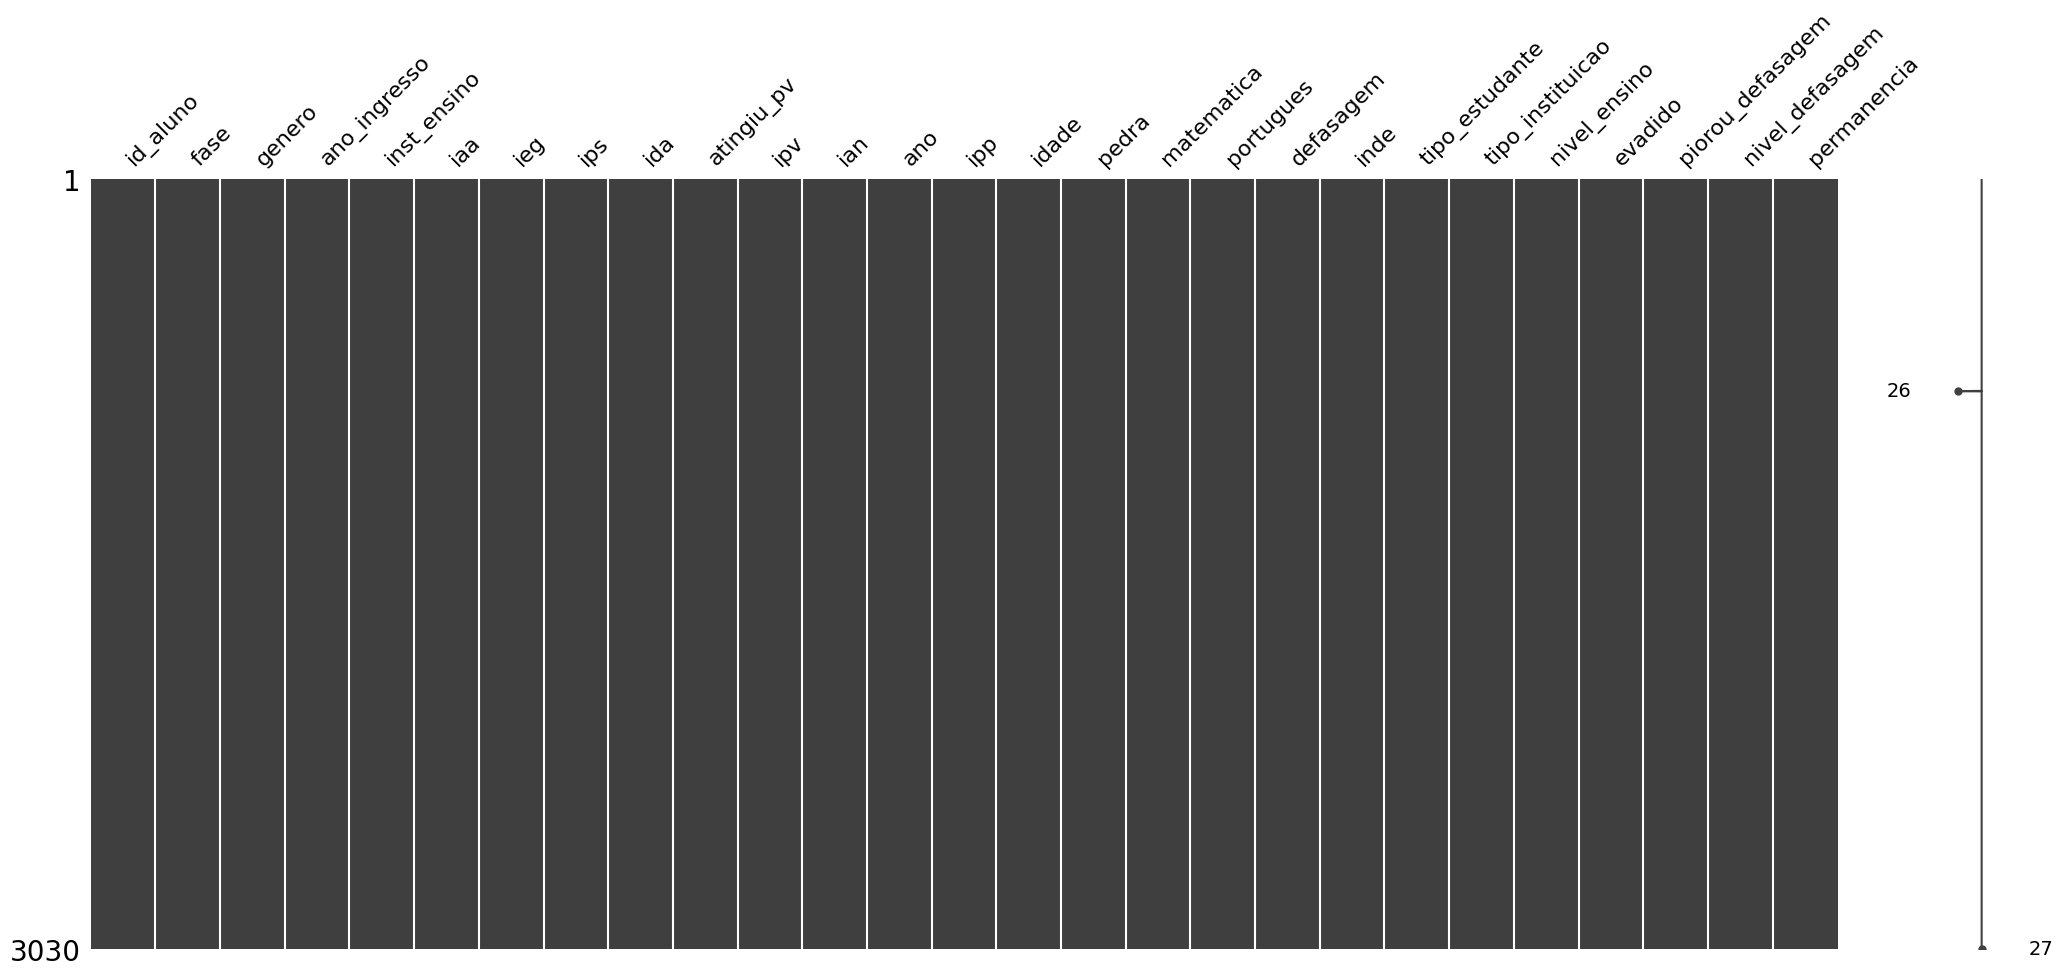

In [ ]:
msno.matrix(df_modelo)

<Axes: >

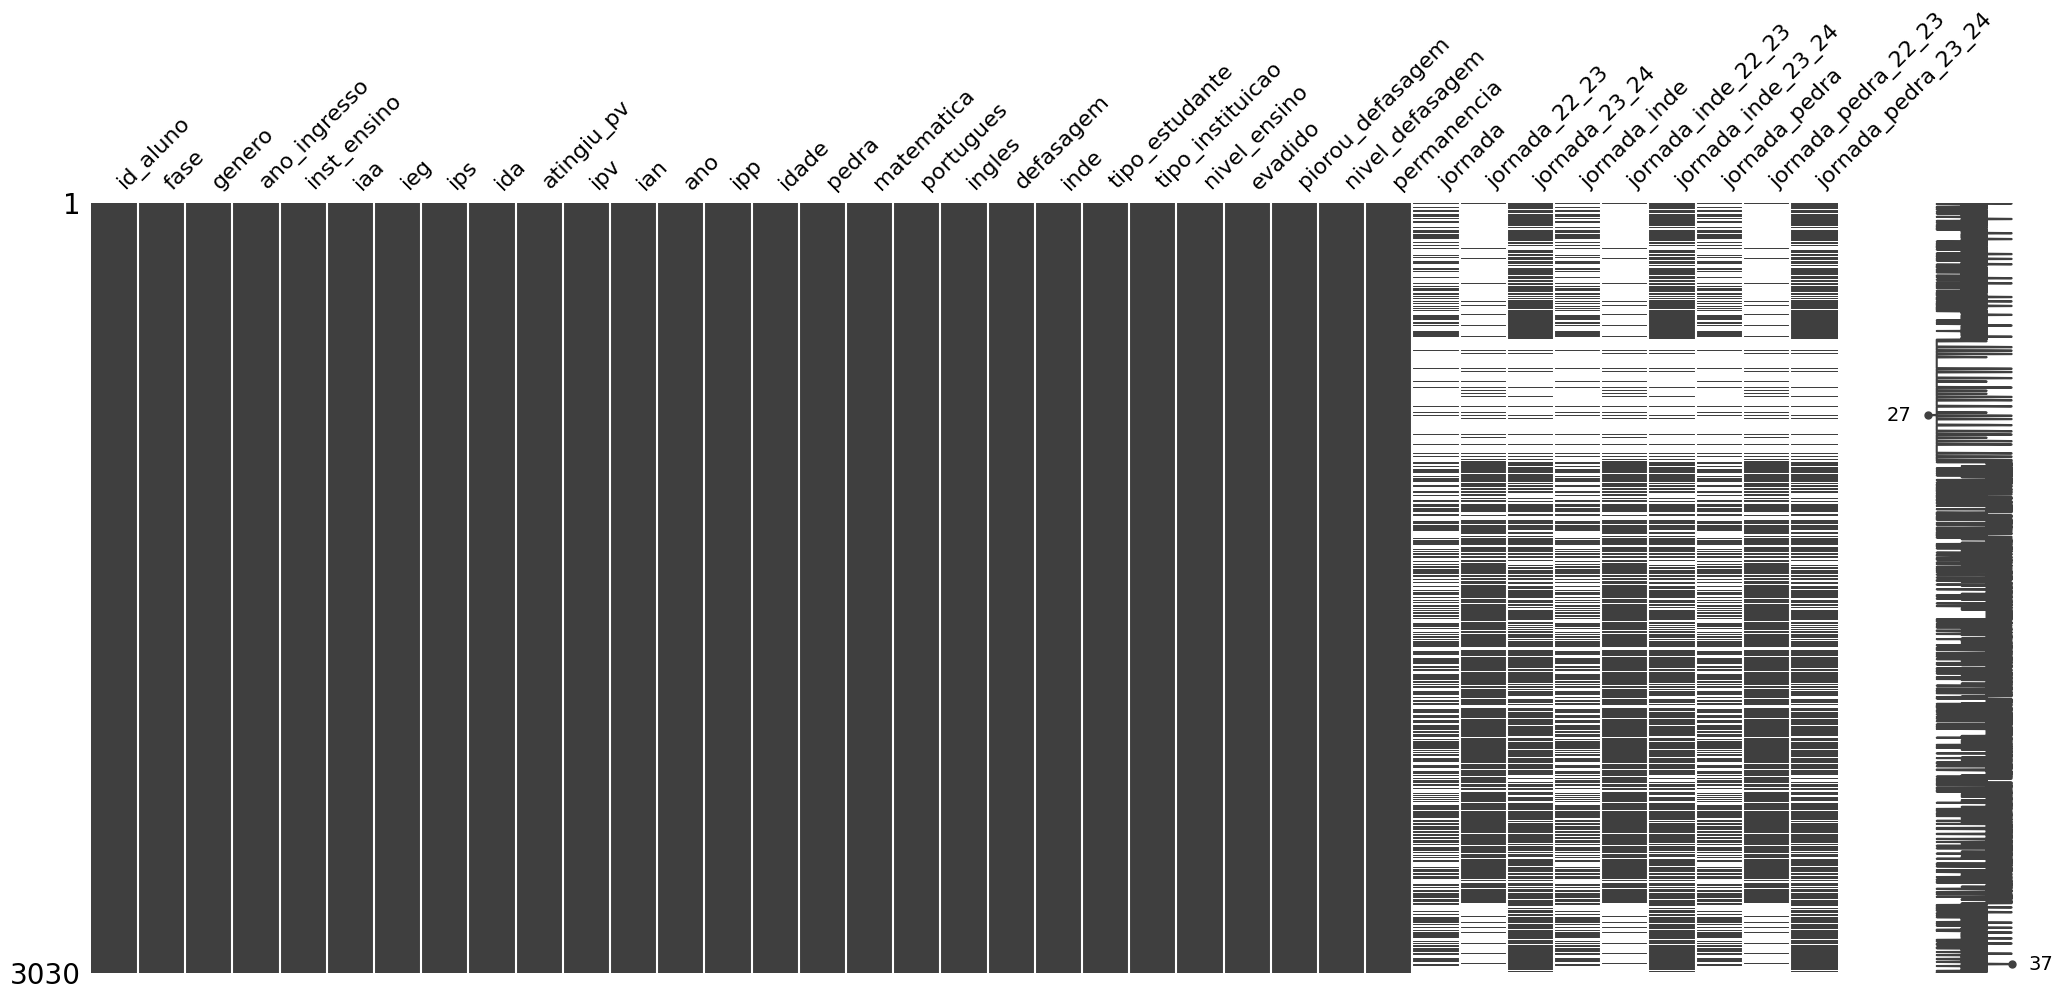

In [ ]:
msno.matrix(df)

# Exportar

In [ ]:
df.to_csv('base_pede_limpa.csv', index=False, encoding='utf-8-sig')
print("DataFrame exported successfully to 'base_pede_limpa.csv'.")

DataFrame exported successfully to 'base_pede_limpa.csv'.


In [ ]:
df.columns

Index(['id_aluno', 'fase', 'genero', 'ano_ingresso', 'inst_ensino', 'iaa',
       'ieg', 'ips', 'ida', 'atingiu_pv', 'ipv', 'ian', 'ano', 'ipp', 'idade',
       'pedra', 'matematica', 'portugues', 'ingles', 'defasagem', 'inde',
       'tipo_estudante', 'tipo_instituicao', 'nivel_ensino', 'evadido',
       'piorou_defasagem', 'nivel_defasagem', 'permanencia', 'jornada',
       'jornada_22_23', 'jornada_23_24', 'jornada_inde', 'jornada_inde_22_23',
       'jornada_inde_23_24', 'jornada_pedra', 'jornada_pedra_22_23',
       'jornada_pedra_23_24'],
      dtype='object')

In [ ]:
df_modelo.to_csv('base_pede_modelo.csv', index=False, encoding='utf-8-sig')
print("DataFrame exported successfully to 'base_pede_modelo.csv'.")

DataFrame exported successfully to 'base_pede_modelo.csv'.
